<a href="https://colab.research.google.com/github/springboard5678x/Emotion-Detection-and-Music-Recommended-system_Batch-27_nov/blob/Ranit-Deria/Notebooks/MoodMate_Milestone2_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from google.colab import drive

drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/MoodMate/datasets'
print("Loading data...")
X = np.load(f'{base_path}/X_faces.npy')
y = np.load(f'{base_path}/y_emotions.npy')

print(f"Loaded Images: {X.shape}")
print(f"Loaded Labels: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on: {X_train.shape[0]} images")
print(f"Validating on: {X_test.shape[0]} images")

Mounted at /content/drive
Loading data...
Loaded Images: (35887, 48, 48, 1)
Loaded Labels: (35887, 7)
Training on: 28709 images
Validating on: 7178 images


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 1)))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(256, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())


model.add(Dense(256, activation='relu', kernel_regularizer=l2(0.01)))
model.add(BatchNormalization())
model.add(Dropout(0.6))

model.add(Dense(7, activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 44, 44, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 44, 44, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 20, 20, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,130,759 (4.31 MB)

 Trainable params: 1,129,031 (4.31 MB)

 Non-trainable params: 1,728 (6.75 KB)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)


early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/MoodMate/moodmate_best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)


print("Starting Training with Augmentation...")
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    validation_data=(X_test, y_test),
    epochs=60,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

Starting Training with Augmentation...
Epoch 1/60


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.1688 - loss: 7.6514
Epoch 1: val_accuracy improved from -inf to 0.25676, saving model to /content/drive/MyDrive/MoodMate/moodmate_best_model.h5


449/449 ━━━━━━━━━━━━━━━━━━━━ 52s 84ms/step - accuracy: 0.1688 - loss: 7.6507 - val_accuracy: 0.2568 - val_loss: 6.0447 - learning_rate: 1.0000e-04
Epoch 2/60
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2250 - loss: 6.5232
Epoch 2: val_accuracy improved from 0.25676 to 0.35344, saving model to /content/drive/MyDrive/MoodMate/moodmate_best_model.h5


449/449 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.2250 - loss: 6.5223 - val_accuracy: 0.3534 - val_loss: 5.3714 - learning_rate: 1.0000e-04
Epoch 3/60
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2524 - loss: 5.7369
Epoch 3: val_accuracy improved from 0.35344 to 0.38534, saving model to /content/drive/MyDrive/MoodMate/moodmate_best_model.h5


...

449/449 ━━━━━━━━━━━━━━━━━━━━ 28s 63ms/step - accuracy: 0.5860 - loss: 1.1661 - val_accuracy: 0.6233 - val_loss: 1.0700 - learning_rate: 2.0000e-05
Epoch 49/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5868 - loss: 1.1587
Epoch 49: val_accuracy did not improve from 0.62329
449/449 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.5868 - loss: 1.1588 - val_accuracy: 0.6209 - val_loss: 1.0634 - learning_rate: 2.0000e-05
Epoch 50/60
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5868 - loss: 1.1421
Epoch 50: val_accuracy did not improve from 0.62329
449/449 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.5868 - loss: 1.1422 - val_accuracy: 0.6209 - val_loss: 1.0685 - learning_rate: 2.0000e-05
Epoch 51/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5851 - loss: 1.1499
Epoch 51: val_accuracy did not improve from 0.62329
449/449 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.5851 - loss: 1.1499 - val_accuracy: 0.6225 - val_loss: 1.0667 - learning_rate: 2.0

449/449 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.5882 - loss: 1.1426 - val_accuracy: 0.6240 - val_loss: 1.0550 - learning_rate: 2.0000e-05
Epoch 53/60
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5914 - loss: 1.1408
Epoch 53: val_accuracy did not improve from 0.62399
449/449 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.5914 - loss: 1.1408 - val_accuracy: 0.6226 - val_loss: 1.0556 - learning_rate: 2.0000e-05
Epoch 54/60
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5894 - loss: 1.1321
Epoch 54: val_accuracy improved from 0.62399 to 0.62664, saving model to /content/drive/MyDrive/MoodMate/moodmate_best_model.h5


449/449 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.5894 - loss: 1.1322 - val_accuracy: 0.6266 - val_loss: 1.0519 - learning_rate: 2.0000e-05
Epoch 55/60
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5933 - loss: 1.1425
Epoch 55: val_accuracy did not improve from 0.62664
449/449 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.5933 - loss: 1.1425 - val_accuracy: 0.6250 - val_loss: 1.0554 - learning_rate: 2.0000e-05
Epoch 56/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5907 - loss: 1.1273
Epoch 56: val_accuracy improved from 0.62664 to 0.62747, saving model to /content/drive/MyDrive/MoodMate/moodmate_best_model.h5


449/449 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.5907 - loss: 1.1273 - val_accuracy: 0.6275 - val_loss: 1.0495 - learning_rate: 2.0000e-05
Epoch 57/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5913 - loss: 1.1353
Epoch 57: val_accuracy did not improve from 0.62747
449/449 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.5913 - loss: 1.1353 - val_accuracy: 0.6257 - val_loss: 1.0518 - learning_rate: 2.0000e-05
Epoch 58/60
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5938 - loss: 1.1312
Epoch 58: val_accuracy improved from 0.62747 to 0.62803, saving model to /content/drive/MyDrive/MoodMate/moodmate_best_model.h5


449/449 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.5938 - loss: 1.1312 - val_accuracy: 0.6280 - val_loss: 1.0414 - learning_rate: 2.0000e-05
Epoch 59/60
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5957 - loss: 1.1294
Epoch 59: val_accuracy did not improve from 0.62803
449/449 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.5957 - loss: 1.1295 - val_accuracy: 0.6255 - val_loss: 1.0469 - learning_rate: 2.0000e-05
Epoch 60/60
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5945 - loss: 1.1274
Epoch 60: val_accuracy did not improve from 0.62803
449/449 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.5945 - loss: 1.1274 - val_accuracy: 0.6265 - val_loss: 1.0471 - learning_rate: 2.0000e-05
Restoring model weights from the end of the best epoch: 58.


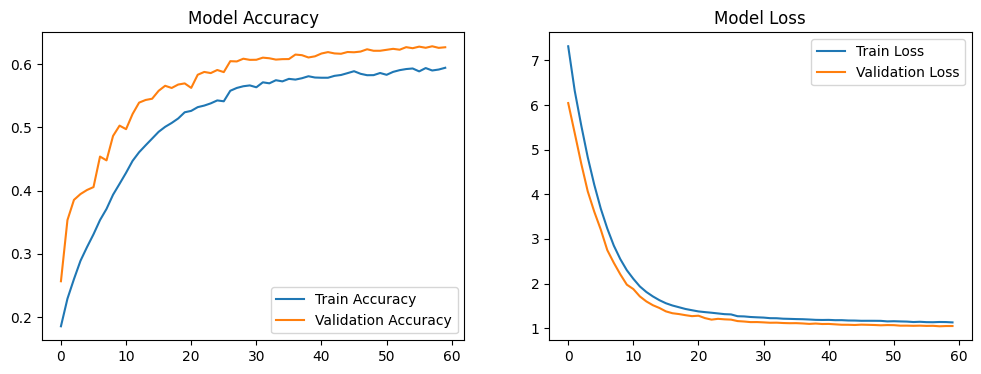

✅ Final Model saved successfully to: /content/drive/MyDrive/MoodMate/moodmate_final_model.h5


In [ ]:
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

# Save final version (though checkpoint already saved the best one)
save_path = '/content/drive/MyDrive/MoodMate/moodmate_final_model.h5'
model.save(save_path)
print(f"✅ Final Model saved successfully to: {save_path}")

Calculating Metrics...
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Angry       0.54      0.58      0.56       985
     Disgust       0.58      0.28      0.38       102
        Fear       0.50      0.35      0.41      1043
       Happy       0.82      0.86      0.84      1765
         Sad       0.53      0.44      0.48      1210
    Surprise       0.73      0.76      0.74       795
     Neutral       0.54      0.70      0.61      1278

    accuracy                           0.63      7178
   macro avg       0.61      0.57      0.57      7178
weighted avg       0.62      0.63      0.62      7178



<Figure size 1200x600 with 0 Axes>

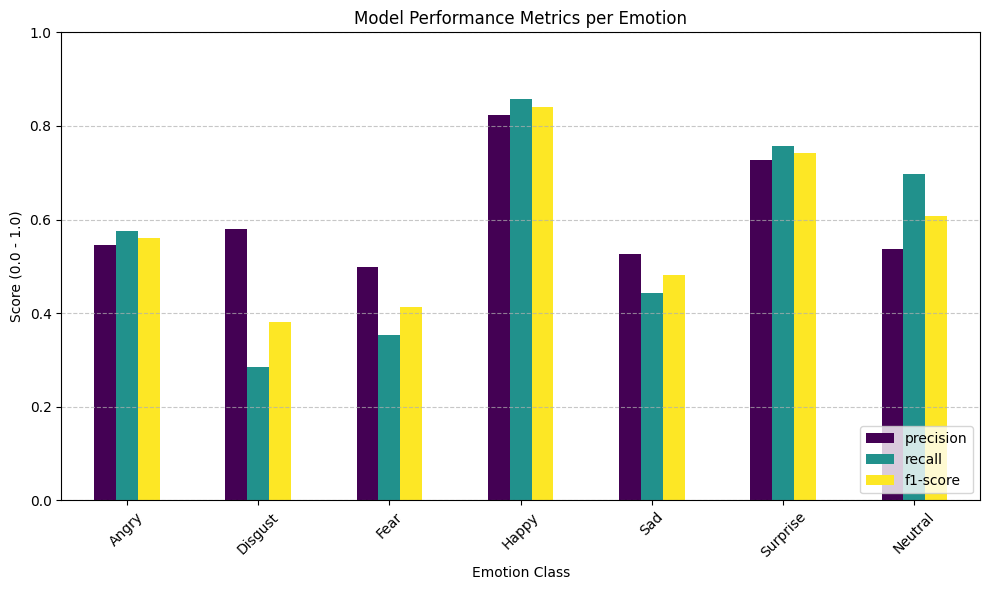

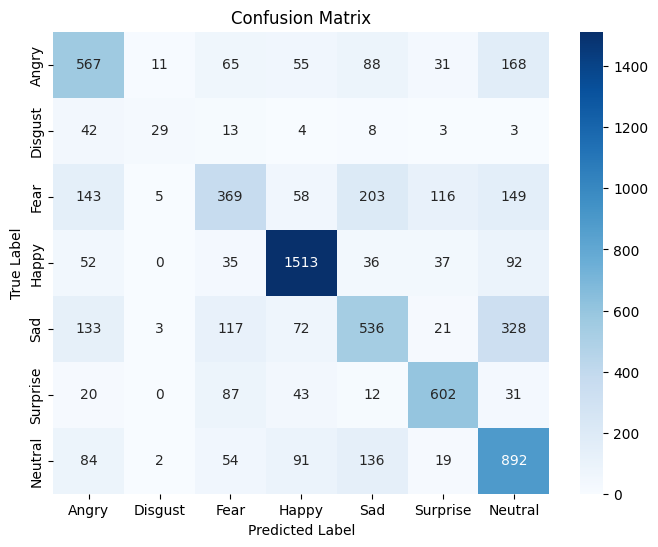

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

print("Calculating Metrics...")
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

report_dict = classification_report(y_true_classes, y_pred_classes, target_names=emotion_labels, output_dict=True)
report_text = classification_report(y_true_classes, y_pred_classes, target_names=emotion_labels)

print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORT")
print("="*60)
print(report_text)
print("="*60)

report_df = pd.DataFrame(report_dict).transpose().iloc[:-3] # Exclude 'accuracy', 'macro avg', 'weighted avg'

plt.figure(figsize=(12, 6))
report_df[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(10, 6), colormap='viridis')

plt.title('Model Performance Metrics per Emotion')
plt.ylabel('Score (0.0 - 1.0)')
plt.xlabel('Emotion Class')
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()